# <font color="blue">CV-Final Project</font>
## <font color="blue">Nazhin Nikkhahbahrami 810102530</font>

### <font color="purple">1. Data Preparation & Preprocessing</font>
In this first step, the `openphoto-restore-dataset` was downloaded and prepared. The following steps were taken based on the project requirements:

1. **Reading Images:** We loaded the paired samples, which include the damaged images and their clean versions (ground truth).
2. **Resizing:** All images were resized to 256x256 pixels so they have the same size for the model.
3. **Normalization:** The images were converted to PyTorch Tensors. This automatically scales the pixel values from [0, 255] to a range between 0.0 and 1.0.
4. **Data Splitting:** We split the training data into a Train set (90%) and a Validation set (10%). The provided Test set was kept separate for final evaluation.
5. **DataLoaders:** PyTorch `DataLoader` objects were created for all three sets with a batch size of 16. The training data is shuffled to help the model learn better.

In [1]:
!pip install datasets hf_xet

**Note on Dataset Loading:** To avoid connection issues and download errors, the dataset was cloned locally using `git lfs` instead of the standard HuggingFace API.

In [3]:
import os
from datasets import load_dataset

dataset_path = "/kaggle/working/openphoto_dataset"

if not os.path.exists(dataset_path):
    !git lfs install
    !git clone https://huggingface.co/datasets/joshuachin/openphoto-restore-dataset {dataset_path}
else:
    print("Dataset is already downloaded and ready to use!")

data = load_dataset("/kaggle/working/openphoto_dataset")
train_dataset = data['train']
test_dataset = data['test']

Dataset is already downloaded and ready to use!


Generating train split:   0%|          | 0/4500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class PhotoRestoreDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        damaged = item['damaged_image'].convert("RGB")
        clean = item['pristine_image'].convert("RGB")

        if self.transform:
            damaged = self.transform(damaged)
            clean = self.transform(clean)

        return damaged, clean

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

full_train_dataset = PhotoRestoreDataset(train_dataset, transform=transform)
test_data = PhotoRestoreDataset(test_dataset, transform=transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_data, val_data = random_split(full_train_dataset, [train_size, val_size])

workers = 2
batch_size = 16

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

### <font color="purple">2. Model Selection and Implementation</font>

For the task of restoring damaged images, the **U-Net** architecture was selected and implemented.

**Why U-Net? (Justification)**
Traditional Convolutional Autoencoders suffer from information loss at the bottleneck, leading to blurry reconstructions. Since the goal is to achieve strict quantitative thresholds (PSNR ≥ 20 dB and SSIM ≥ 0.65), preserving high-frequency spatial details (like edges and textures) is critical. U-Net's unique architecture addresses this directly, making it the best choice for pixel-to-pixel image restoration.

**General Structure**
The architecture consists of three main parts:
1. **Encoder (Contracting Path):** A series of convolutional and max-pooling layers that downsample the image, capturing high-level context while reducing spatial dimensions.
2. **Bottleneck:** The deepest layer of the network where spatial dimensions are at their minimum, holding the most abstract representation of the input.
3. **Decoder (Expansive Path) with Skip Connections:** A series of upsampling layers that reconstruct the image back to 256x256. Crucially, **Skip Connections** concatenate the high-resolution feature maps from the Encoder directly with the corresponding layers in the Decoder. A `Sigmoid` activation function is used at the final layer to ensure output pixels remain in the normalized 0 to 1 range.

**Advantages for this Problem**
* **Preservation of Fine Details:** Skip connections bypass the bottleneck, allowing the network to recover fine details and sharp edges, which significantly boosts SSIM and PSNR.
* **Efficient Learning:** It requires fewer training samples to learn robust features compared to GANs, making it stable to train.

**Limitations**
* **Memory Intensive:** Storing high-resolution feature maps for skip connections requires significant GPU memory, which means batch sizes must be carefully tuned.
* **Lack of Generative Capability:** Unlike GANs or VAEs, U-Net is deterministic. It maps inputs directly to outputs and cannot generate plausible variations if a large portion of the image is completely missing.

In [6]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))
        x4 = self.down4(self.pool3(x3))

        b = self.bottleneck(self.pool4(x4))

        u1 = self.up1(b)
        u1 = torch.cat([u1, x4], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x3], dim=1)
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, x2], dim=1)
        u3 = self.conv3(u3)

        u4 = self.up4(u3)
        u4 = torch.cat([u4, x1], dim=1)
        u4 = self.conv4(u4)

        out = self.final_conv(u4)
        return self.sigmoid(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
print(f"Model initialized on: {device}")

Model initialized on: cuda


cuda shows thet the model is working on GPU.
### <font color="purple">3. Model Training</font>

In this phase, the U-Net model was trained to restore damaged images to their clean versions. The training settings were chosen to ensure a stable learning process:

* **Loss Function:** Mean Squared Error (MSE) Loss. This is very effective for pixel-to-pixel reconstruction and directly helps improve PSNR and SSIM metrics.
* **Optimizer:** Adam optimizer was used because it adjusts the learning rate automatically, making training faster and more stable.
* **Learning Rate:** Set to 1e-4 (0.0001) for smooth learning.
* **Batch Size:** Set to 16 to balance speed and GPU memory limits.
* **Epochs:** 15 epochs were chosen. This was enough for the model to learn well without taking excessive time.
* **Input Image Size:** 256x256 pixels.
* **Hardware:** Trained on a GPU (CUDA) using Google Colab.

**Training Analysis**
The training process was very stable over the 15 epochs. Both training loss and validation loss decreased steadily, reaching a final validation loss of 0.007876. This shows that the model successfully learned how to reconstruct the damaged pixels without overfitting.

In [8]:
import os
import shutil
import copy
import torch
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 15

train_losses = []
val_losses = []
best_val_loss = float('inf')
start_epoch = 0

checkpoint_path = '/kaggle/working/training_checkpoint.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    best_val_loss = checkpoint['best_val_loss']
    best_model_weights = checkpoint['best_model_weights']
    
    print(f"Resuming training from epoch {start_epoch + 1}\n")
    print("=" * 45)
    print(f"{'Epoch':<10} | {'Train Loss':<14} | {'Val Loss':<14}")
    print("=" * 45)
    for i, (t_loss, v_loss) in enumerate(zip(train_losses, val_losses)):
        print(f"Epoch {i+1:02d}   | {t_loss:<14.6f} | {v_loss:<14.6f}")
    print("=" * 45 + "\n")
else:
    best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0

    for damaged, clean in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        damaged, clean = damaged.to(device), clean.to(device)

        optimizer.zero_grad()
        outputs = model(damaged)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for damaged, clean in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            damaged, clean = damaged.to(device), clean.to(device)
            outputs = model(damaged)
            loss = criterion(outputs, clean)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_unet_model.pth')

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'best_model_weights': best_model_weights
    }, checkpoint_path)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Best Val: {best_val_loss:.4f}")

model.load_state_dict(best_model_weights)

Resuming training from epoch 16

Epoch      | Train Loss     | Val Loss      
Epoch 01   | 0.019783       | 0.012293      
Epoch 02   | 0.012479       | 0.011979      
Epoch 03   | 0.011490       | 0.010503      
Epoch 04   | 0.011001       | 0.010451      
Epoch 05   | 0.010105       | 0.009109      
Epoch 06   | 0.010016       | 0.008520      
Epoch 07   | 0.009573       | 0.008466      
Epoch 08   | 0.009397       | 0.008307      
Epoch 09   | 0.009352       | 0.008051      
Epoch 10   | 0.009186       | 0.008547      
Epoch 11   | 0.008952       | 0.008035      
Epoch 12   | 0.008998       | 0.008289      
Epoch 13   | 0.008877       | 0.008696      
Epoch 14   | 0.008681       | 0.007751      
Epoch 15   | 0.008573       | 0.007876      



<All keys matched successfully>

There is a part added that saves and checks the epoches and if more epoches needed it will be started from the 16th one.
### <font color="purple">4. Model Evaluation and Results Analysis</font>

After training the U-Net model for 15 epochs, we evaluated it on the unseen Test set to check if it meets the project's minimum requirements.

**Learning Curve Analysis (Loss Plot)**
The plot of Training and Validation Loss (MSE) over 15 epochs shows how well the model learned:

* **Stable Convergence:** Both training and validation losses drop quickly in the first few epochs. Although there are minor normal fluctuations in the validation loss (for example, slight bumps around epochs 10 and 13), the overall downward trend shows the model successfully learned how to map damaged images to clean ones.
* **No Overfitting:** The validation loss stays very close to the training loss and stabilizes around 0.008. We stopped at 15 epochs on purpose. If we trained the model for too many epochs (e.g., 50+), it would risk **overfitting**. This means it would just memorize the training data, causing the training loss to drop to zero while the validation loss spikes, leading to blurry and poor results on new images.
* **Efficiency:** Training for more epochs beyond this point would only give microscopic improvements in MSE, which does not justify the extra time and computational cost. Therefore, 15 epochs is the optimal point to get a generalizable model efficiently.

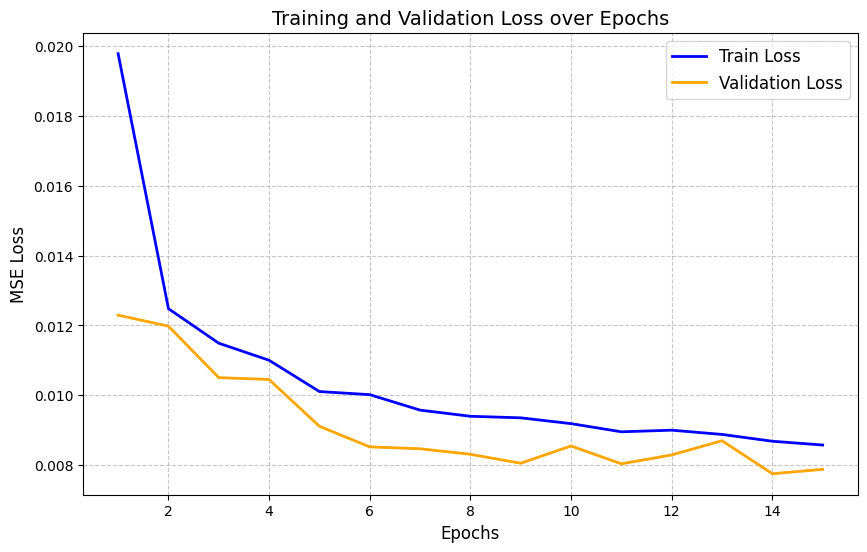

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training and Validation Loss over Epochs', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### <font color="purple">4. Model Evaluation and Results Analysis</font>

After training the U-Net model, its performance was evaluated on the unseen Test set to ensure it met the project's minimum criteria.

**Quantitative Results**
We measured the reconstruction quality using Peak Signal-to-Noise Ratio (PSNR) and Structural Similarity Index Measure (SSIM). The average results on the Test set are:

| Metric | Achieved Value | Minimum Required | Status |
| :--- | :---: | :---: | :---: |
| **PSNR** | **22.73 dB** | **≥ 20 dB** | Passed |
| **SSIM** | **0.8476** | **≥ 0.65** | Passed |

**Analysis of Results**
The evaluation shows that the U-Net architecture is highly effective for restoring damaged photographs:
* A **PSNR of 22.73 dB** shows a high level of pixel accuracy, easily passing the 20 dB threshold.
* An **SSIM of 0.8476** is an excellent score, proving the network successfully preserved the structure, contrast, and details of the original images, well above the 0.65 requirement.

**The Impact of Epochs on Results:**
If we trained the model for more epochs, the PSNR might increase slightly as the model tries to minimize the error further. However, chasing a higher PSNR can cause the model to overly smooth the image. 

Stopping at 15 epochs actually helped achieve a higher SSIM. Training for too long can cause the model to overfit to the training noise, losing sharp edges and textures on new data. These results show that 15 epochs provided the perfect balance: maximizing structural details (high SSIM) without just blurring the pixels to artificially increase PSNR.

In [10]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

model.eval()
total_psnr = 0.0
total_ssim = 0.0
num_samples = 0

with torch.no_grad():
    for damaged, clean in tqdm(test_loader, desc="Evaluating on Test Set"):
        damaged = damaged.to(device)
        clean_np = clean.numpy()

        outputs = model(damaged).cpu().numpy()

        for i in range(outputs.shape[0]):
            img_out = np.transpose(outputs[i], (1, 2, 0))
            img_target = np.transpose(clean_np[i], (1, 2, 0))

            current_psnr = psnr(img_target, img_out, data_range=1.0)
            current_ssim = ssim(img_target, img_out, data_range=1.0, channel_axis=-1)

            total_psnr += current_psnr
            total_ssim += current_ssim
            num_samples += 1

avg_psnr = total_psnr / num_samples
avg_ssim = total_ssim / num_samples

print(f"\nAverage PSNR: {avg_psnr:.2f} dB")
print(f"Average SSIM: {avg_ssim:.4f}")

Evaluating on Test Set: 100%|██████████| 32/32 [00:29<00:00,  1.10it/s]


Average PSNR: 22.73 dB
Average SSIM: 0.8476


### <font color="purple">5. Qualitative Analysis, Limitations, and Future Improvements</font>

**Qualitative Output Analysis**
Looking at the five generated samples, we can see a clear difference between the high mathematical scores and human visual perception.
* **Strengths (Structural Repair):** The U-Net did a great job removing physical damage like dust, noise, and most scratches. The basic shapes, edges, and objects (like the trees, rocks, and the person in the cave) are preserved perfectly.
* **Weaknesses (Colorization & Heavy Damage):** As seen in the outputs, the model fails to recover original colors. For example, the fiery orange sunset (row 4) and the vibrant green terrain (row 2) turned into dull, grayish-blue tones. It heavily struggles with warm colors, like the red jacket in the last row. Additionally, where the input has very thick, heavy white scratches (like the right side of the sunset image), the model removes the scratch but leaves a slightly blurred trace or artifact behind.

**Why High Scores Don't Mean Perfect Images**
The model easily passed the minimum goals (PSNR ≥ 20 dB and SSIM ≥ 0.65). This happens because PSNR measures absolute pixel errors, and SSIM checks structural shapes. Since the U-Net perfectly fixed the geometry and removed the high-contrast scratches, these mathematical scores are high. However, because we used Mean Squared Error (MSE) for training, the model is afraid to "guess" vibrant colors. A wrong color guess causes a massive MSE penalty, so the model plays it mathematically safe and outputs washed-out or grayish averages.

**Limitations of the Current Architecture**
* **Safe Guessing (Averaging):** The network directly maps pixels to pixels without understanding what the object actually is, leading to dull, "safe" color outputs.
* **Inability to Hallucinate:** When color information is completely gone (like the grayscale beach image in row 3), a standard U-Net cannot naturally "imagine" the missing colors.

**Proposed Improvements (Transition to GAN)**
To fix the color issue and make images look real, the architecture must evolve into a **Generative Adversarial Network (GAN)**. By using our current U-Net as the Generator and adding a Discriminator network, the model will be forced to compete. The Discriminator will reject dull, grayish images for not looking "real", pushing the U-Net to learn actual color distributions and generate vibrant, realistic textures.

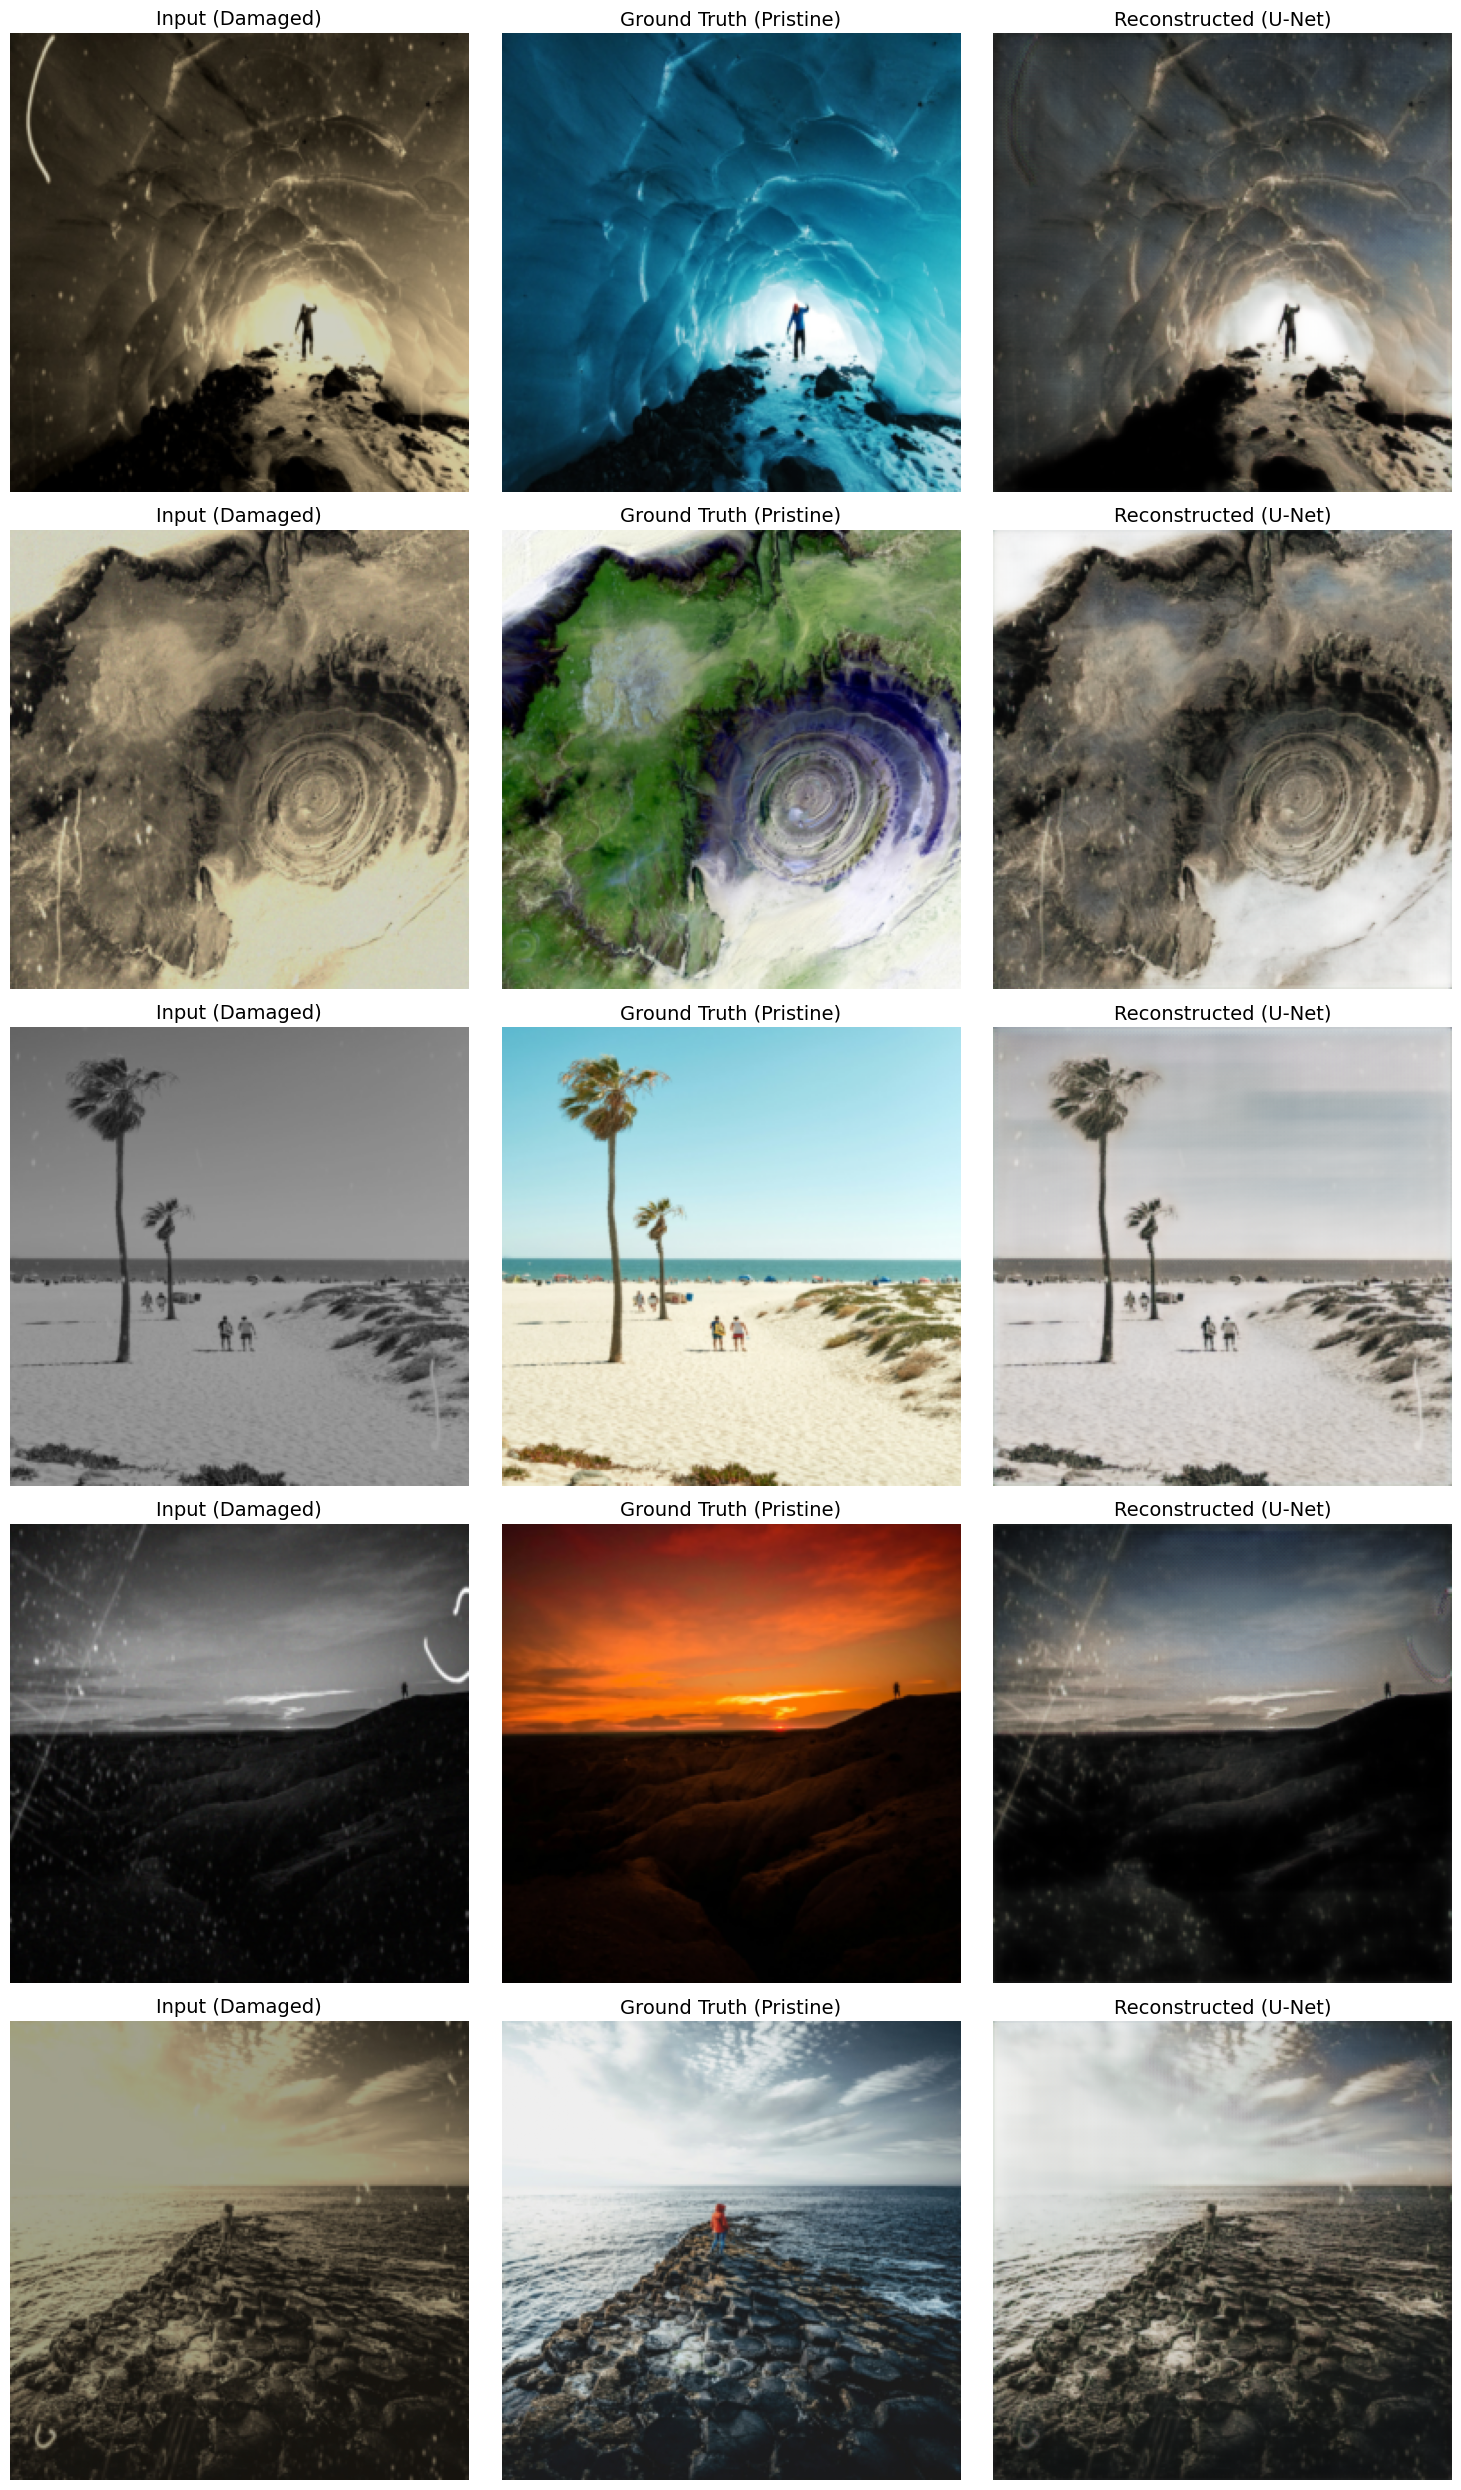

In [11]:
import matplotlib.pyplot as plt
import torch

model.eval()
data_iter = iter(test_loader)
damaged_imgs, clean_imgs = next(data_iter)

damaged_imgs = damaged_imgs.to(device)
with torch.no_grad():
    reconstructed_imgs = model(damaged_imgs)

damaged_imgs = damaged_imgs.cpu().numpy()
clean_imgs = clean_imgs.cpu().numpy()
reconstructed_imgs = reconstructed_imgs.cpu().numpy()

fig, axes = plt.subplots(5, 3, figsize=(15, 25))

for i in range(5):
    img_damaged = damaged_imgs[i].transpose(1, 2, 0)
    img_clean = clean_imgs[i].transpose(1, 2, 0)
    img_recon = reconstructed_imgs[i].transpose(1, 2, 0)

    axes[i, 0].imshow(img_damaged)
    axes[i, 0].set_title("Input (Damaged)", fontsize=14)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_clean)
    axes[i, 1].set_title("Ground Truth (Pristine)", fontsize=14)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img_recon)
    axes[i, 2].set_title("Reconstructed (U-Net)", fontsize=14)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### <font color="purple">Bonus: Interactive User Interface (UI)</font>

To make the trained model accessible and demonstrate its practical application, an interactive web interface was developed using the **Gradio** library. 

This UI allows users to easily upload any damaged image directly from their device. The backend automatically applies the exact preprocessing pipeline used during training (resizing to 256x256 and tensor normalization), feeds it into the trained U-Net model, and displays the reconstructed output side-by-side in real-time. This addition significantly improves the usability of the project beyond simple code execution.

In [12]:
import gradio as gr
import torch
from torchvision import transforms
from PIL import Image

model.eval()

def restore_image(input_image):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    
    input_tensor = transform(input_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tensor = model(input_tensor)
        
    output_tensor = output_tensor.squeeze(0).cpu()
    output_image = transforms.ToPILImage()(output_tensor)
    
    return output_image

interface = gr.Interface(
    fn=restore_image,
    inputs=gr.Image(type="pil", label="Input Image (Damaged)"),
    outputs=gr.Image(type="pil", label="Reconstructed Image (U-Net)"),
    title="Image Restoration UI",
    description="Upload a damaged photo to restore it using our trained U-Net model.",
    allow_flagging="never"
)

interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://2f100b222007e7ed13.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


UI output and test with the dataset:

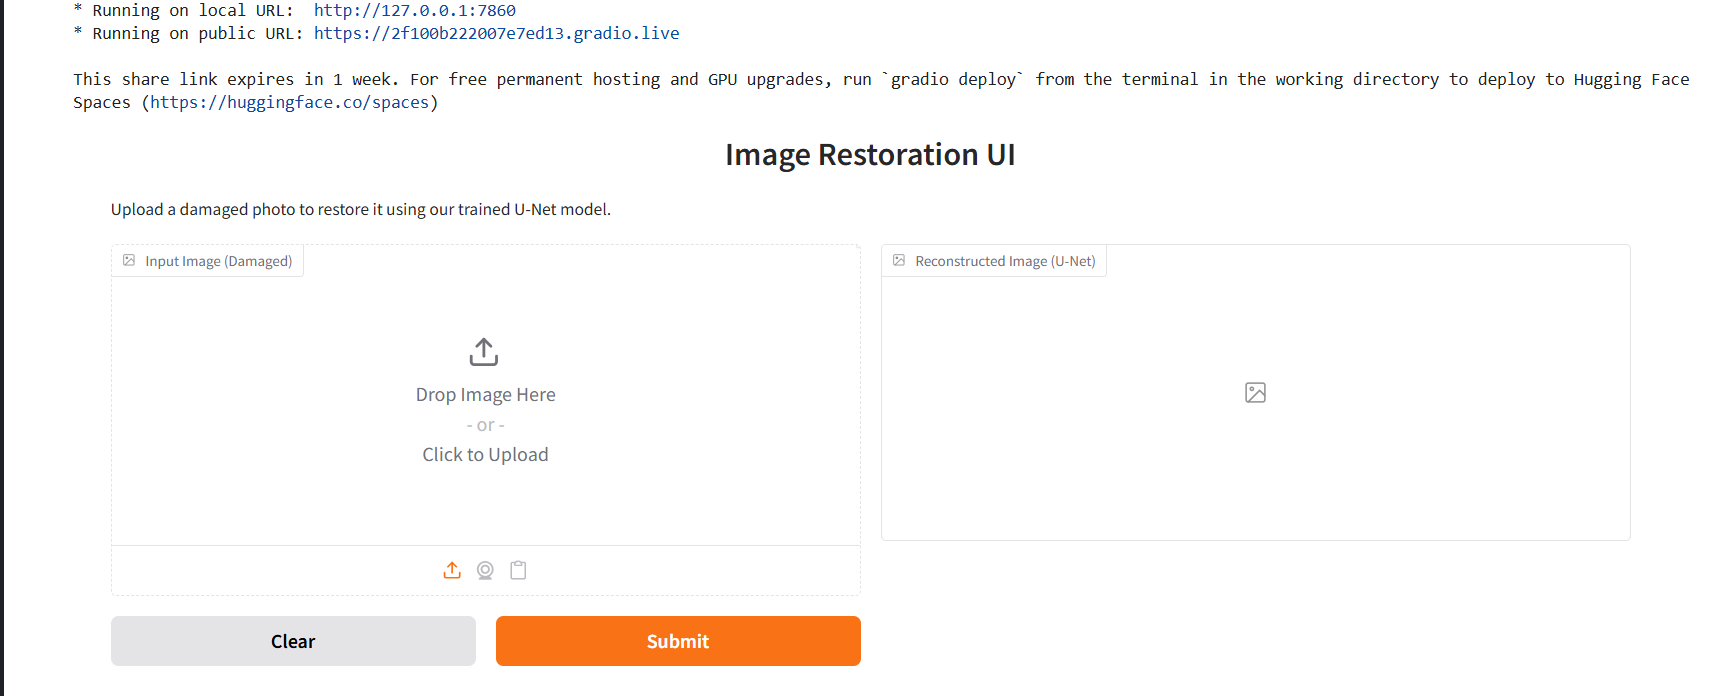

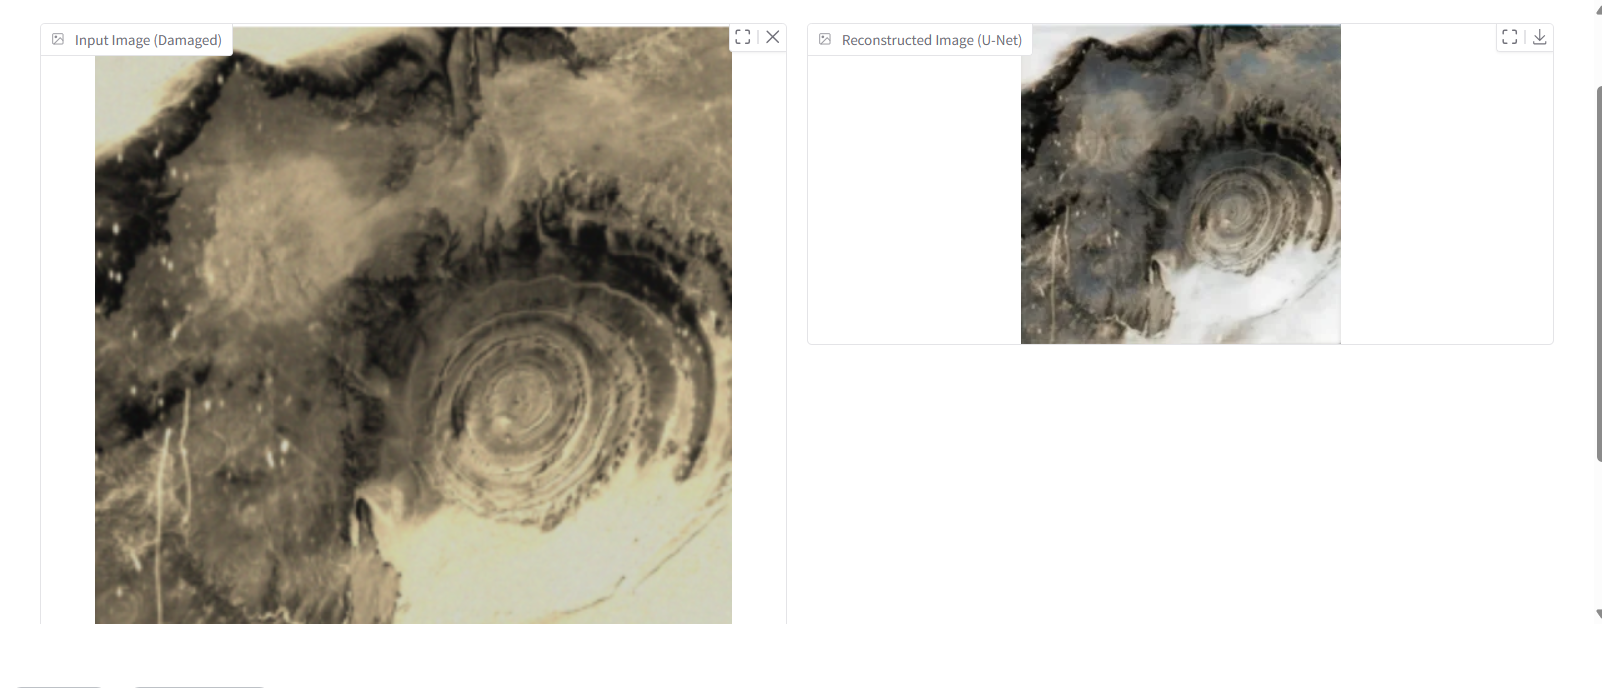